<a href="https://colab.research.google.com/github/kassingit/IA-EMBARQUEE/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — The Artificial Neuron, Logistic Regression & Model Evaluation
**Polytech Nice Sophia — Embedded Artificial Intelligence** | *Student Workbook*


>  **Instructions:** Complete every cell marked with `# ── TODO ──`.

##  Learning Objectives (Pedagogical Goals)
- **Model:** Understand the Artificial Neuron and Activation Functions.
- **Algorithm:** Implemant Logistic Regression trained with Gradient Descent.
- **Evaluation:** Calculate rigorous metrics (Confusion Matrix, Precision, Recall, Accuracy).
- **Validation:** Perform a Cross-Validation study on imbalanced data.

In [ ]:
# ── Setup ────────────────────────────────────────────────────────────────────
# !pip install -q numpy matplotlib scikit-learn torch torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

np.random.seed(42)
try:    plt.style.use("seaborn-v0_8-whitegrid")
except: plt.style.use("seaborn-whitegrid")
plt.rcParams["figure.figsize"] = (10,5); plt.rcParams["font.size"]=12
print("Setup complete!")

Setup complete!


---
## Course Reminders 1

### 1.1 The Artificial Neuron & Activation Functions
An artificial neuron computes a weighted sum $z = \sum w_i x_i + b$, then applies a non-linear **activation function** $f(z)$.
- **Sigmoid:** $\sigma(z) = 1 / (1 + e^{-z})$. Range $(0,1)$. Ideal for probabilities.
- **Tanh:** Range $(-1,1)$. Zero-centred.
- **ReLU:** $\max(0, z)$.

Range $[0,\infty[$. Prevents vanishing gradient.

### 1.2 Logistic Regression & Binary Cross-Entropy (BCE)
Logistic regression is essentially a single neuron with a Sigmoid activation.
Instead of MSE, we use **BCE loss**:
$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log\hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$
Gradient update (identical form to linear regression):

$dz = \hat{y}-y$

$w \leftarrow w - \eta \frac{1}{m}X^\top dz$

$b \leftarrow b - \eta \frac{1}{m} \sum dz$

### 1.3 Confusion Matrix & Metrics
| | **Predicted Positive (1)** | **Predicted Negative (0)** |
|-|----------------|----------------|
| **Actual Positive (1)** | TP (True Positive) | FN (Missed Diagnosis) |
| **Actual Negative (0)** | FP (False Alarm) | TN (True Negative) |

$\text{Recall} = \frac{TP}{TP+FN}$, $\quad \text{Precision} = \frac{TP}{TP+FP}$, $\quad \text{Accuracy} = \frac{TP+TN}{Total}$


### 1.4 Useful link

Numpy documentation: https://numpy.org/doc/stable/

---
##  Section 1 - Experiments

### Step 1: Activation Functions

In [ ]:
# ── Step 1: Activation functions ─────────────────────────────────────────────
def sigmoid(z):
    # ── TODO ─────────────────────────────────────────────────────────────────
    # Implement the sigmoid function: 1 / (1 + exp(-z)).
    # Hint: use np.clip(z, -500, 500) to avoid overflow warnings.
    #raise NotImplementedError("TODO: Implement Sigmoid")
    # ─────────────────────────────────────────────────────────────────────────
    return 1/(1+np.exp(np.clip(-z, -500, 500)))

def tanh(z):    return np.tanh(z)
def relu(z):    return np.maximum(0, z)

### Step 2: Breast Cancer Dataset & BCE Loss
We classify medical features (30 parameters) into Malignant (1) vs Benign (0).

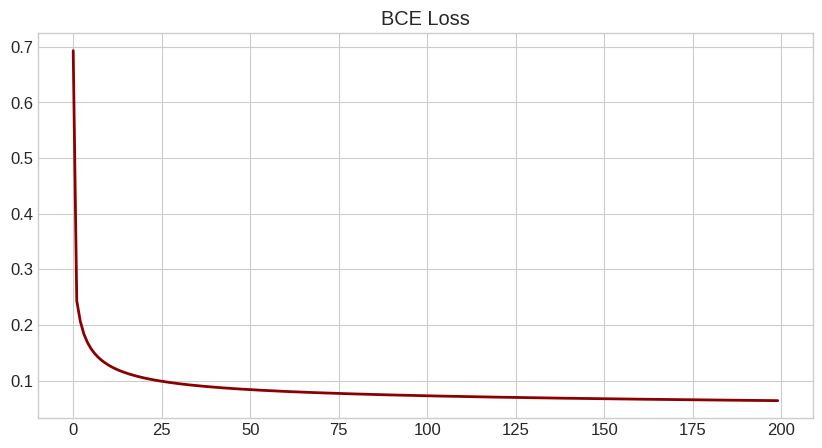

In [ ]:
# ── Step 2: Logistic Regression & BCE Loss ───────────────────────────────────
bc = load_breast_cancer(); X_bc, y_bc = bc.data, bc.target
y_bc = 1 - y_bc  # Invert so 1 = Malignant (disease)

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc)
m_bc, s_bc = X_tr.mean(0), X_tr.std(0)
X_tr_n, X_te_n = (X_tr - m_bc) / s_bc, (X_te - m_bc) / s_bc

def bce_loss(y_true, y_pred, eps=1e-9):
    # ── TODO ─────────────────────────────────────────────────────────────────
    # Implement Binary Cross Entropy using the mathematical formula from Section 1.2.
    # Note: Use np.clip(y_pred, eps, 1-eps) instead of raw y_pred to avoid log(0) errors.
    #raise NotImplementedError("TODO: Implement BCE Loss")
    # ─────────────────────────────────────────────────────────────────────────
    y_pred2 = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred2) + (1.0 - y_true) * np.log(1.0 - y_pred2))

class NeuronClassifier:
    def __init__(self, lr=0.1, epochs=300):
        self.lr, self.epochs = lr, epochs

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n); self.b = 0.0
        self.history = []
        for _ in range(self.epochs):
            # ── TODO ─────────────────────────────────────────────────────────
            # 1. Forward pass (Compute y_hat. Refer to Section 1.1 / 1.2)
            z = (X @ self.w) + self.b
            y_hat = sigmoid(z) # <- replace

            # 2. Append loss to history
            self.history.append(bce_loss(y, y_hat))

            # 3. Gradients (Compute dz, dw, db using the formulas from Section 1.2)
            dz = y_hat - y # <- replace
            dw = (X.T@dz)/m # <- replace
            db = np.mean(dz)# <- redzplace

            # ─────────────────────────────────────────────────────────────────
            # Update (Provided)
            self.w -= self.lr * dw; self.b -= self.lr * db
        return self

    def predict_proba(self, X): return sigmoid(X @ self.w + self.b)
    def predict(self, X, threshold=0.5): return (self.predict_proba(X) >= threshold).astype(int)

# Train model
model_bc = NeuronClassifier(lr=0.5, epochs=200).fit(X_tr_n, y_tr)
plt.plot(model_bc.history, "darkred", lw=2); plt.title("BCE Loss"); plt.show()

### Step 3: Metrics Dashboard (Accuracy, Precision, Recall)

In [ ]:
# ── Step 3: Confusion Matrix & Metrics ───────────────────────────────────────
y_te_pred = model_bc.predict(X_te_n, threshold=0.5)

# ── TODO ─────────────────────────────────────────────────────────────────────
# Compute TP, TN, FP, FN manually using boolean conditions (e.g. np.sum((...)))
# Refer to the Confusion Matrix table in Section 1.3 to formulate your logic.
TP = np.sum((y_te == 1) & (y_te_pred==1)) # <- replace
TN = np.sum((y_te == 0) & (y_te_pred==0)) # <- replace
FP = np.sum((y_te == 0) & (y_te_pred==1)) # <- replace
FN = np.sum((y_te == 1) & (y_te_pred==0)) # <- replace
# ─────────────────────────────────────────────────────────────────────────────

rec  = TP / (TP + FN) if (TP+FN)>0 else 0
prec = TP / (TP + FP) if (TP+FP)>0 else 0
acc  = (TP + TN) / len(y_te)

print(f"Accuracy: {(TP + TN) / len(y_te):.2f}")
print(f"Recall (Sensitivity): {rec*100:.1f}%")
print(f"Precision:            {prec*100:.1f}%")

Accuracy: 0.98
Recall (Sensitivity): 95.3%
Precision:            98.4%


---
## Course Reminders 2

### 1.1 The Multi-Layer Perceptron (MLP)
Unlike TP2's single layer, an MLP contains **Hidden Layers**.
Matrix formulation for a 1-hidden-layer network (Input $X$, Hidden $H$, Output $Y$):
- **$Z_1 = X \cdot W_1 + b_1$**  |  **$A_1 = f(Z_1)$** *(e.g., Tanh or ReLU)*
- **$Z_2 = A_1 \cdot W_2 + b_2$** |  **$\hat{Y} = \sigma(Z_2)$** *(for binary output)*

### 1.2 Backpropagation (The Chain Rule)
To update $W_1$, we compute errors backwards:
- Output Error: $dZ_2 = \hat{Y} - Y$
- Hidden Error: $dZ_1 = (dZ_2 \cdot W_2^\top) \odot f'(Z_1)$
- Gradients Layer 2: $dW_2 = \frac{1}{m} A_1^\top \cdot dZ_2$  |  $db_2 = \frac{1}{m} \sum dZ_2$
- Gradients Layer 1: $dW_1 = \frac{1}{m} X^\top \cdot dZ_1$  |  $db_1 = \frac{1}{m} \sum dZ_1$

### 1.3 Binary Cross Entropy (BCE) Loss
$$ \mathcal{L} = -\frac{1}{m}\sum\left[Y\log(\hat{Y}) + (1-Y)\log(1-\hat{Y})\right] $$

### 1.4 Useful link

Pytorch documentation: https://docs.pytorch.org/docs/2.14/index.html

### Step 1: Motivation — The Dense Noisy XOR Problem
Instead of the 4-point academic XOR, we use a **dense and noisy XOR** with 500 points per quadrant.

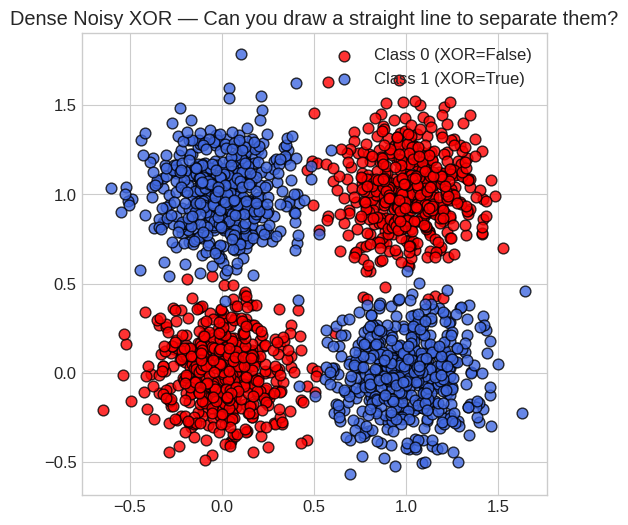

Dataset size: 2000 points (500 per quadrant)


In [ ]:
# ── Step 1a: Dense Noisy XOR (Provided) ───────────────────────────────────────
np.random.seed(42)
n_per_quadrant = 500
q00 = np.random.randn(n_per_quadrant, 2)*0.20 + [0, 0]
q11 = np.random.randn(n_per_quadrant, 2)*0.20 + [1, 1]
q01 = np.random.randn(n_per_quadrant, 2)*0.20 + [0, 1]
q10 = np.random.randn(n_per_quadrant, 2)*0.20 + [1, 0]
X_xor = np.vstack([q00, q11, q01, q10])
y_xor = np.array([0]*n_per_quadrant + [0]*n_per_quadrant +
                 [1]*n_per_quadrant + [1]*n_per_quadrant).reshape(-1, 1)

plt.figure(figsize=(6,6))
plt.scatter(X_xor[y_xor[:,0]==0, 0], X_xor[y_xor[:,0]==0, 1], c="red",       s=60, edgecolors="k", alpha=0.8, label="Class 0 (XOR=False)")
plt.scatter(X_xor[y_xor[:,0]==1, 0], X_xor[y_xor[:,0]==1, 1], c="royalblue", s=60, edgecolors="k", alpha=0.8, label="Class 1 (XOR=True)")
plt.title("Dense Noisy XOR — Can you draw a straight line to separate them?")
plt.legend(); plt.grid(True); plt.show()
print(f"Dataset size: {len(X_xor)} points ({n_per_quadrant} per quadrant)")

### Step 1b: Single Neuron (TP2 approach) fails on XOR

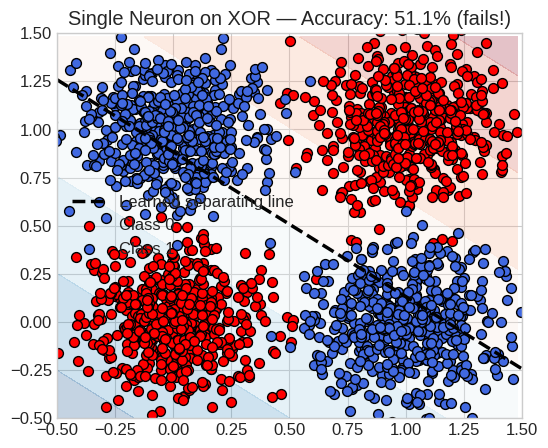

 Single neuron: 51.1% — barely above random!
Why? A straight line CANNOT separate 4 quadrants. We need hidden layers.
   Separating line: y = -0.75*x + 0.88


In [ ]:
# ── Step 1b: Single Neuron on XOR (Provided — Observe the failure) ──────────────
class SingleNeuron:
    def __init__(self, lr=0.5, epochs=2000):
        self.lr, self.epochs = lr, epochs
    def fit(self, X, y):
        m, n = X.shape; self.w = np.zeros(n); self.b = 0.0
        for _ in range(self.epochs):
            y_hat = sigmoid(X @ self.w + self.b)
            dz = y_hat - y.ravel()
            self.w -= self.lr * (X.T @ dz) / m
            self.b -= self.lr * dz.mean()
    def predict(self, X): return (sigmoid(X @ self.w + self.b) >= 0.5).astype(int)

neuron = SingleNeuron()
neuron.fit(X_xor, y_xor)
acc_neuron = np.mean(neuron.predict(X_xor) == y_xor.ravel()) * 100

h = 0.02
xx, yy = np.meshgrid(np.arange(-0.5, 1.5, h), np.arange(-0.5, 1.5, h))
Z_n = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ neuron.w + neuron.b).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z_n, alpha=0.25, cmap="RdBu")
# Draw the learned separating line: w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
x_line = np.linspace(-0.5, 1.5, 200)
y_line = -(neuron.w[0] * x_line + neuron.b) / neuron.w[1]
plt.plot(x_line, y_line, 'k--', lw=2.5, label='Learned separating line')
plt.scatter(X_xor[y_xor[:,0]==0,0], X_xor[y_xor[:,0]==0,1], c="red",       s=50, edgecolors="k", label="Class 0")
plt.scatter(X_xor[y_xor[:,0]==1,0], X_xor[y_xor[:,0]==1,1], c="royalblue", s=50, edgecolors="k", label="Class 1")
plt.title(f"Single Neuron on XOR — Accuracy: {acc_neuron:.1f}% (fails!)")
plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
plt.legend(); plt.show()
print(f" Single neuron: {acc_neuron:.1f}% — barely above random!")
print("Why? A straight line CANNOT separate 4 quadrants. We need hidden layers.")
print(f"   Separating line: y = {-neuron.w[0]/neuron.w[1]:.2f}*x + {-neuron.b/neuron.w[1]:.2f}")

### Step 2 & 3: Manual MLP Forward & Backward Pass (NumPy)
Implement a `[2 -> 4 -> 1]` MLP using only matrix multiplication (`np.dot` or `@`).

In [ ]:
# ── Step 2 & 3: Manual MLP Implementation ────────────────────────────────────
def d_tanh(z):  return 1.0 - np.tanh(z)**2  # Derivative of tanh(z)

class ManualMLP:
    def __init__(self, input_dim=2, hidden_dim=4, output_dim=1, lr=0.1):
        self.lr = lr
        # Xavier initialisation: avoids vanishing gradients with tanh
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(1.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def forward(self, X):
        self.X = X
        # ── TODO: Layer 1 ────────────────────────────────────────────────────
        # Refer to the formulas in Section 1.1 to compute Z1 and the activation A1 (use Tanh).
        self.Z1 = self.X @ self.W1  + self.b1 # <- replace
        self.A1 = np.tanh(self.Z1) # <- replace

        # ── TODO: Layer 2 ────────────────────────────────────────────────────
        # Refer to Section 1.1 to compute Z2 and the final activation A2 (use Sigmoid).
        self.Z2 = self.A1 @ self.W2 + self.b2 # <- replace
        self.A2 = sigmoid(self.Z2) # <- replace
        # ─────────────────────────────────────────────────────────────────────
        return self.A2

    def backward(self, Y):
        m = Y.shape[0]
        # ── TODO: 1. Output Layer Error & Gradients ──────────────────────────
        # Implement the gradients for the output layer (dZ2, dW2, db2).
        # Refer to the mathematical formulas in Section 1.2.
        # Hint: use np.sum(..., axis=0, keepdims=True) for the bias gradient.
        dZ2 = self.A2 - Y # <- replace
        dW2 = (1/m) * ((self.A1).T) @  dZ2 # <- replace
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True) # <- replace

        # ── TODO: 2. Hidden Layer Error & Gradients ──────────────────────────
        # Implement the errors and gradients for the hidden layer (dZ1, dW1, db1).
        # Refer to Section 1.2. Hint: use the provided `d_tanh(self.Z1)` helper.
        dZ1 = (dZ2 @ (self.W2).T) * d_tanh(self.Z1) # <- replace
        dW1 = (1/m)*((self.X).T) @ dZ1 # <- replace
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True) # <- replace
        # ─────────────────────────────────────────────────────────────────────

        # 3. Update Weights (Gradient Descent)
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def train(self, X, Y, epochs=5000):
        history = []
        for i in range(epochs):
            A2 = self.forward(X)
            # ── TODO: BCE Loss ───────────────────────────────────────────────
            # Implement BCE Loss using A2 and Y (Refer to Section 1.3).
            # Note: Add 1e-9 to A2 and (1-A2) inside the logarithms to avoid log(0) errors.
            eps = 1e-9
            Y_pred = np.clip(A2,eps,1-eps)
            loss = -np.mean(Y * np.log(Y_pred) + (1.0 - Y) * np.log(1.0 - Y_pred)) # <- resplace

            # ─────────────────────────────────────────────────────────────────
            self.backward(Y)
            history.append(loss)
        return history

### Step 4: Parameter Tuning for the MLP
The exact architecture and learning parameters are critical. By default, the code below is set to `hidden_dim=1` and `lr=0.0`.
- With only 1 hidden neuron, the MLP is essentially a linear classifier, so it will fail on XOR just like the single neuron did.
- With a learning rate of 0, it µwon't even learn anything!

** Your Task:**
1. Run the cell below and observe the flat loss and failed decision boundary.
2. Adjust `hidden_dim` (e.g., try 8) and the learning rate `lr` (e.g., try 0.2).
3. Re-run until the MLP successfully learns the non-linear boundaries.

MLP accuracy on dense XOR: 99.1%


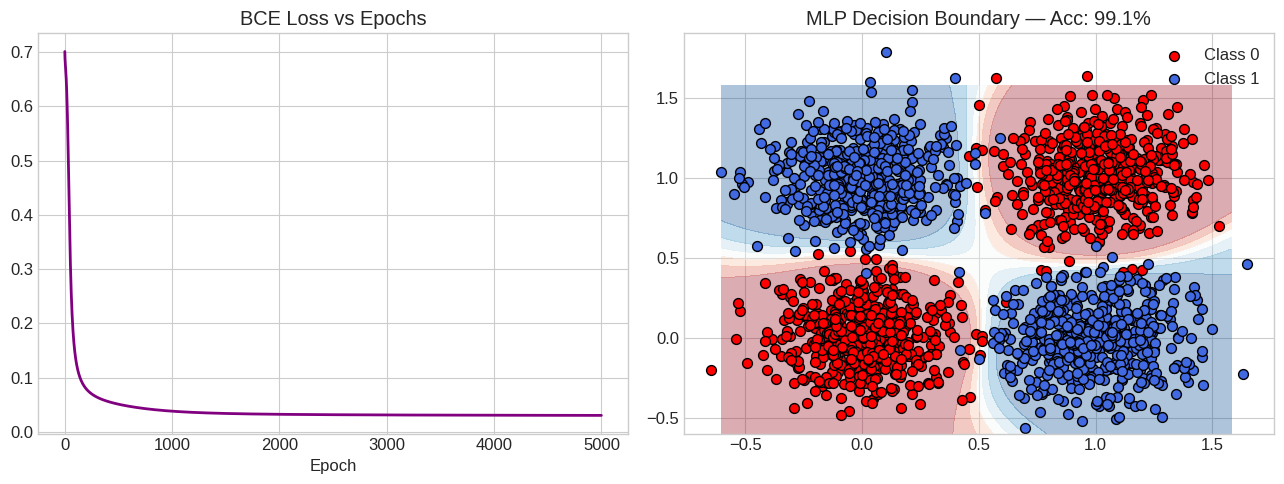

In [ ]:
# ── Step 4: Train MLP on Dense XOR ───────────────────────────────────────────
np.random.seed(42)  # For reproducible results

# ── TODO: Find the right parameters! ─────────────────────────────────────────
mlp = ManualMLP(hidden_dim=6, lr=0.8)  # <- Change these values!
# ─────────────────────────────────────────────────────────────────────────────

history = mlp.train(X_xor, y_xor, epochs=5000)
y_pred_mlp = (mlp.forward(X_xor) >= 0.5).astype(int)
acc_mlp = np.mean(y_pred_mlp.ravel() == y_xor.ravel()) * 100
print(f"MLP accuracy on dense XOR: {acc_mlp:.1f}%")

h = 0.02
xx, yy = np.meshgrid(np.arange(-0.6, 1.6, h), np.arange(-0.6, 1.6, h))
Z = mlp.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history, color="purple", lw=2)
axes[0].set_title("BCE Loss vs Epochs"); axes[0].set_xlabel("Epoch")
axes[1].contourf(xx, yy, Z, alpha=0.35, cmap="RdBu")
axes[1].scatter(X_xor[y_xor[:,0]==0,0], X_xor[y_xor[:,0]==0,1], c="red",       s=50, edgecolors="k", label="Class 0")
axes[1].scatter(X_xor[y_xor[:,0]==1,0], X_xor[y_xor[:,0]==1,1], c="royalblue", s=50, edgecolors="k", label="Class 1")
axes[1].set_title(f"MLP Decision Boundary — Acc: {acc_mlp:.1f}%")
axes[1].legend(); plt.tight_layout(); plt.show()

### Step 5: Transition to Frameworks (PyTorch) & MNIST
Writing derivatives by hand is terrible for 100-layer networks. Let's use **PyTorch**'s Autograd!

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.70MB/s]


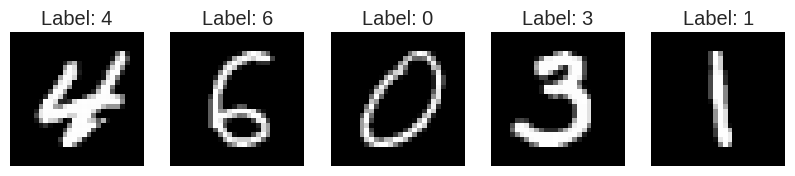

In [ ]:
# ── Step 5: Load MNIST with PyTorch ──────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

### Step 6: Building a Deep PyTorch MLP
We will flatten the 28x28 image into a 784 vec, pass it through a hidden layer, and output 10 probabilities.

In [ ]:
# ── Step 6: Define and Train PyTorch MLP ─────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# ── TODO: 1. Build the PyTorch Model ─────────────────────────────────────────
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        # Define:

        # Layers documentation can be found here : https://docs.pytorch.org/docs/2.14/nn.html
        # Your model should be : flatten -> fc1 -> relu -> dropout(0.2) -> fc2(128,10)
        # Fc1 is defined below

        self.fc1 = nn.Linear(28 * 28, 128)

        self.flatten = nn.Flatten() # turn (number_of_images, 1, 28, 28) => (number_of_images,128)
        self.relu = nn.ReLU() # remove negative part for more complex models
        self.dropout = nn.Dropout(0.2) # loss of 20% of the neurone to make the models simple
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        # Chain the operations together: flatten -> fc1 -> relu -> dropout -> fc2
        x = self.flatten(x)
        x = self.fc1 (x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x
# ─────────────────────────────────────────────────────────────────────────────

model_pt = TorchMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Training PyTorch MLP...")
for epoch in range(epochs):
    # --- TRAIN ---
    model_pt.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        # ── TODO: 2. Backpropagation with PyTorch ────────────────────────────
        # Write 3 lines to:
        # 1. Clear previous gradients (zero_grad)
        # 2. Compute new gradients (backward)
        # 3. Update weights (step)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ─────────────────────────────────────────────────────────────────────

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # --- VALIDATION (Provided) ---
    model_pt.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pt(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / val_total)
    val_accs.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}, Acc: {train_accs[-1]*100:.2f}% | Val Acc: {val_accs[-1]*100:.2f}%")

Training on: cpu
Training PyTorch MLP...
Epoch [1/10], Loss: 0.3925, Acc: 89.16% | Val Acc: 94.10%
Epoch [2/10], Loss: 0.1949, Acc: 94.41% | Val Acc: 95.58%
Epoch [3/10], Loss: 0.1458, Acc: 95.84% | Val Acc: 96.70%
Epoch [4/10], Loss: 0.1183, Acc: 96.59% | Val Acc: 96.93%
Epoch [5/10], Loss: 0.0984, Acc: 97.05% | Val Acc: 97.42%
Epoch [6/10], Loss: 0.0858, Acc: 97.39% | Val Acc: 97.38%
Epoch [7/10], Loss: 0.0744, Acc: 97.69% | Val Acc: 97.53%
Epoch [8/10], Loss: 0.0654, Acc: 97.98% | Val Acc: 97.53%
Epoch [9/10], Loss: 0.0592, Acc: 98.13% | Val Acc: 97.67%
Epoch [10/10], Loss: 0.0522, Acc: 98.29% | Val Acc: 97.85%


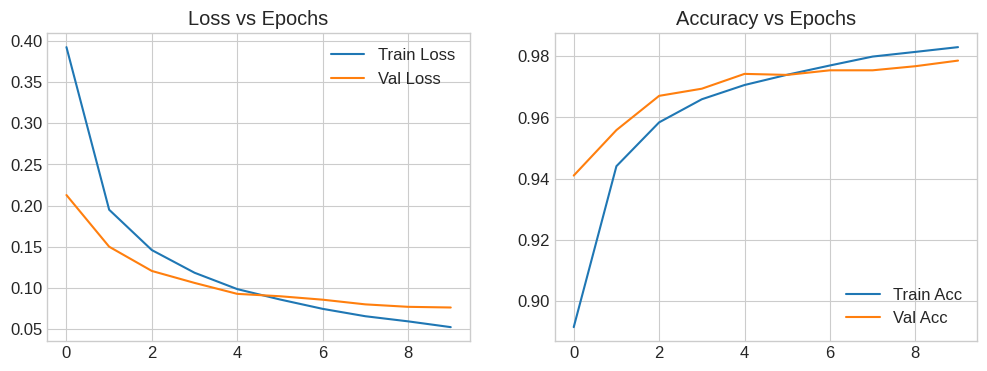

Final Test Accuracy: 98.00%


In [ ]:
# ── Plot Learning Curves ─────────────────────────────────────────────────────
if train_losses:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(train_losses, label='Train Loss')
    axs[0].plot(val_losses, label='Val Loss')
    axs[0].set_title('Loss vs Epochs'); axs[0].legend()

    axs[1].plot(train_accs, label='Train Acc')
    axs[1].plot(val_accs, label='Val Acc')
    axs[1].set_title('Accuracy vs Epochs'); axs[1].legend()
    plt.show()

    # Final Test Evaluation
    model_pt.eval()
    test_correct, test_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pt(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = test_correct / test_total
    print(f"Final Test Accuracy: {test_acc*100:.2f}%")

### Step 7: Multi-Class Confusion Matrix

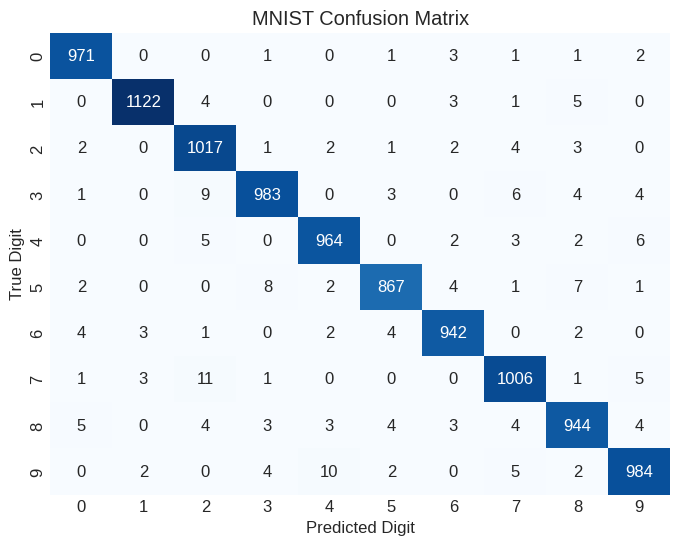

In [ ]:
# ── Step 7: Confusion Matrix (MNIST) ─────────────────────────────────────────
if all_labels:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("MNIST Confusion Matrix")
    plt.xlabel("Predicted Digit"); plt.ylabel("True Digit")
    plt.show()